In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# url de la api para obtener información
url = "https://api.thedogapi.com/v1/breeds"

In [3]:
# Implementación de la API
respuesta = requests.get(url)
data = respuesta.json()
df = pd.DataFrame(data)

In [6]:
# Consultar los primeros 5 registros
df.head()

,weight,height,id,name,bred_for,breed_group,life_span,temperament,origin,reference_image_id,country_code,description,history
0,"{'imperial': '6 - 13', 'metric': '3 - 6'}","{'imperial': '9 - 11.5', 'metric': '23 - 29'}",1,Affenpinscher,"Small rodent hunting, lapdog",Toy,10 - 12 years,"Stubborn, Curious, Playful, Adventurous, Activ...","Germany, France",BJa4kxc4X,NaN,NaN,NaN
1,"{'imperial': '50 - 60', 'metric': '23 - 27'}","{'imperial': '25 - 27', 'metric': '64 - 69'}",2,Afghan Hound,Coursing and hunting,Hound,10 - 13 years,"Aloof, Clownish, Dignified, Independent, Happy","Afghanistan, Iran, Pakistan",hMyT4CDXR,AG,NaN,NaN
2,"{'imperial': '44 - 66', 'metric': '20 - 30'}","{'imperial': '30', 'metric': '76'}",3,African Hunting Dog,A wild pack animal,NaN,11 years,"Wild, Hardworking, Dutiful",,rkiByec47,NaN,NaN,NaN
3,"{'imperial': '40 - 65', 'metric': '18 - 29'}","{'imperial': '21 - 23', 'metric': '53 - 58'}",4,Airedale Terrier,"Badger, otter hunting",Terrier,10 - 13 years,"Outgoing, Friendly, Alert, Confident, Intellig...","United Kingdom, England",1-7cgoZSh,NaN,NaN,NaN
4,"{'imperial': '90 - 120', 'metric': '41 - 54'}","{'imperial': '28 - 34', 'metric': '71 - 86'}",5,Akbash Dog,Sheep guarding,Working,10 - 12 years,"Loyal, Independent, Intelligent, Brave",,26pHT3Qk7,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   weight              172 non-null    object
 1   height              172 non-null    object
 2   id                  172 non-null    int64 
 3   name                172 non-null    object
 4   bred_for            151 non-null    object
 5   breed_group         156 non-null    object
 6   life_span           172 non-null    object
 7   temperament         168 non-null    object
 8   origin              5 non-null      object
 9   reference_image_id  172 non-null    object
 10  country_code        12 non-null     object
 11  description         1 non-null      object
 12  history             2 non-null      object
dtypes: int64(1), object(12)
memory usage: 17.6+ KB


In [8]:
df.describe()

,id
count,172.000000
mean,125.505814
std,81.121200
min,1.000000
25%,53.750000
50%,120.500000
75%,201.750000
max,264.000000


In [10]:
# seleccionar solo el primer numero para la columna "life_span"
numeros = []
for span in df["life_span"]:
    numero =  int(span.split()[0])
    numeros.append(numero)

df["life_span"] = numeros

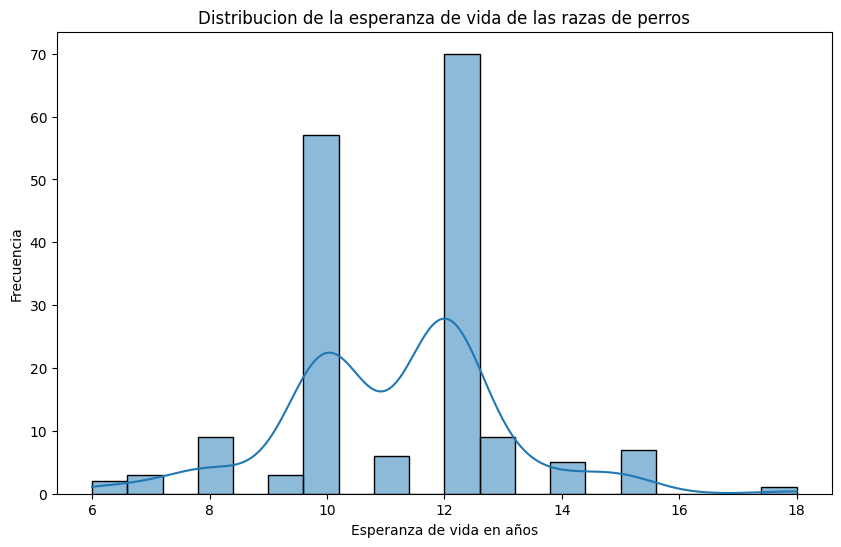

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["life_span"], kde=True, bins=20)
plt.title("Distribucion de la esperanza de vida de las razas de perros")
plt.xlabel("Esperanza de vida en años")
plt.ylabel("Frecuencia");

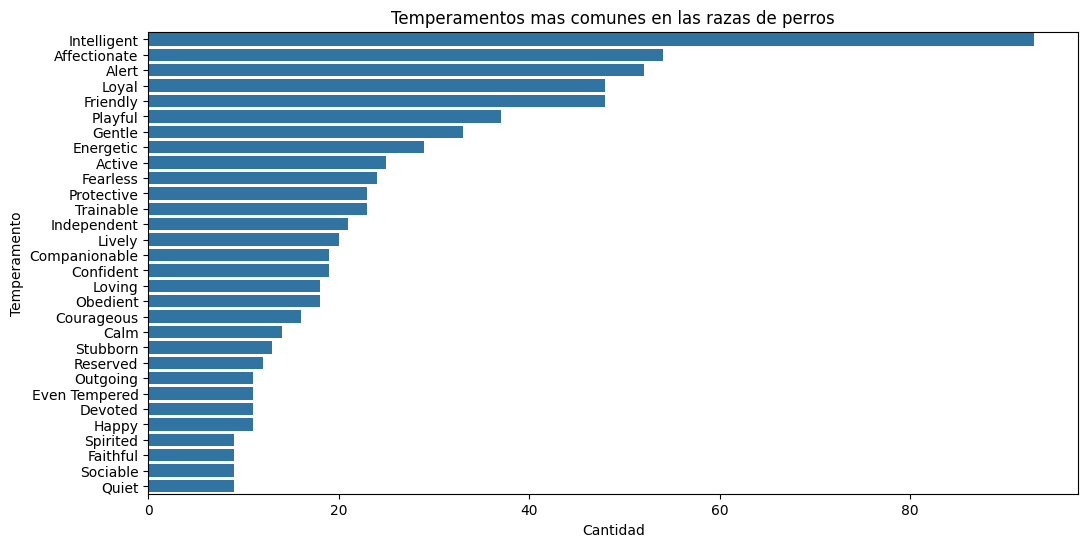

In [13]:
# Creacion de un grafico de barras con los temperamentos mas frequentes
# Dividir los temperamentos en una lista de palabras

lista_temperamentos = df["temperament"].dropna().str.split(', ')
temperamentos = []
for sublista in lista_temperamentos:
    for temperamento in sublista:
        temperamentos.append(temperamento)

# Contar los temperamentos usando pandas
serie_temperamentos = pd.Series(temperamentos)
conteo_temperamentos = serie_temperamentos.value_counts().head(30).reset_index()
conteo_temperamentos.columns = ["Temperamento", "Conteo"]

# Graficar los temperamentos mas comunes
plt.figure(figsize=(12,6))
sns.barplot(x="Conteo", y="Temperamento", data=conteo_temperamentos)
plt.title("Temperamentos mas comunes en las razas de perros")
plt.xlabel("Cantidad")
plt.ylabel("Temperamento");